# SheafMPNN: Sheaf Message Passing Neural Networks

Welcome to the interactive tutorial for the **Neural Sheaf Diffusion** repository, a comprehensive PyTorch Geometric (PyG) framework for **Sheaf Message Passing Neural Networks (SheafMPNNs)**.

This notebook bridges the gap between algebraic topology and practical deep learning. It provides a guided introduction to the mathematical foundations of **cellular sheaves** and the **Sheaf Laplacian**, demonstrating how these geometry-aware architectures overcome the heterophily and oversmoothing limitations of standard GNNs.

### Repository Features
This repository provides the necessary tools to train, evaluate, and experiment with SheafMPNNs. 
Key features include:

* **Core Architectures:** Implementations of Neural Sheaf Diffusion (NSD) supporting **Diagonal**, **General**, and **Orthogonal** restriction map variants.
* **Experimental Pipeline:** A reproducible training suite powered by **PyTorch Geometric** and **PyTorch Lightning**, integrated with **Optuna** for automated hyperparameter sweeps.
* **Built-in Benchmarks:** Automated data loading and cross-validation management for a suite of standard heterophilic and homophilic graph datasets.

### Notebook Roadmap
We have structured this tutorial as a journey from abstract topology to working code. Step-by-step, we will:

1. **Build Geometric Intuition:** Visualize the core concepts behind cellular sheaves and stalks.
2. **Construct the Math:** Explore the algebraic machinery that drives sheaf diffusion operators.
3. **Dissect the Architecture:** Map these topological equations directly to our PyTorch implementation.
4. **Train the Models:** Run practical, end-to-end experiments on benchmark datasets.

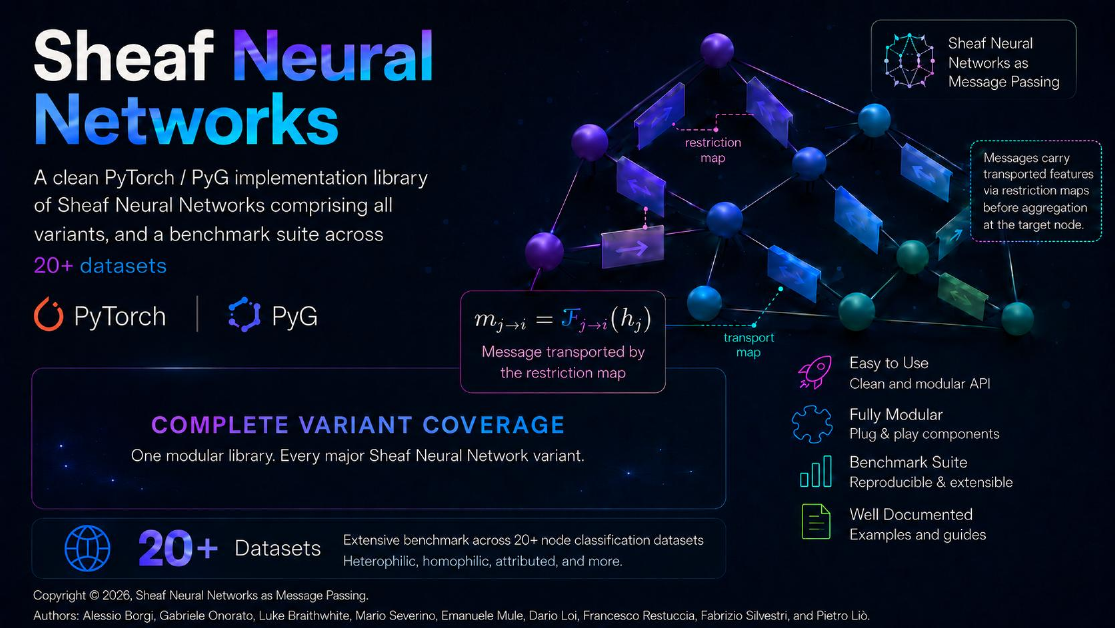

## Table of Contents

1. [Introduction](#1-introduction)

2. [Environment Setup and Imports](#2-env-setup)

3. [Cellular Sheaves and Sheaf Laplacian](#3-cellular-sheaves-and-sheaf-neural-networks)
    * [Cellular Sheaves](#introduction-to-cellular-sheaves)
    * [The Sheaf Laplacian](#motivation--the-sheaf-laplacian)
    * [Recovering Classical Graph Diffusion](#recovering-classical-graph-diffusion)

4. [Dataset Pipeline](#4-dataset-pipeline)
    * [Loading Datasets and Graph Inspection](#loading-datasets)

5. [Neural Sheaf Diffusion](#5-neural-sheaf-diffusion)
    * [Message Passing Formulation](#message-passing-formulation)
    * [Restriction Maps Parameterizations](#restriction-map-parameterizations)
    * [Instantiating NSD Model](#instantiating-nsd-models)

6. [Training Pipeline](#6-training-pipeline)
    * [Experiment Configuration](#experiment-configuration)
    * [Data and Model Modules](#data-and-model-modules)
    * [Training Execution](#training-execution)
    * [Results Verification](#results-verification)

7. [Configuration and Reproducibility](#7-configuration-and-reproducibility)
    * [Configuration Objects and Presets](#configuration-objects)
    * [The Cross-Validation Loop](#cross-validation)
    * [Statistical Aggregation](#results-aggregation)

8. [Interpreting Learned Sheaf Geometry](#8-interpreting-learned-sheaf-geometry)
    * [Global Map Extraction](#global-map-extraction)
    * [Visualization Utilities](#heatmap-analysis)
    * [Heatmap Analysis](#heatmap-analysis)
    * [Marginal Distributions](#marginal-distributions)
    * [Geometric Clustering](#geometric-clustering)
    * [Top-K Exemplar Edges](#top-k-exemplars)

<a id="1-introduction"></a>
# 1. Introduction

Standard Graph Neural Networks (GNNs) assume **homophily**, that connected nodes are inherently similar. By relying on the standard graph Laplacian, they smooth features directly across edges. However, in real-world **heterophilic** graphs, this uniform neighbor-averaging leads to oversmoothing and destroys valuable local information.

This repository provides an optimized framework to overcome these limitations using **Cellular Sheaf Theory**. Rather than forcing uniform smoothing, **Sheaf Message Passing Neural Networks (SheafMPNN)** learn the underlying geometric structure of the data.

By predicting *restriction maps* to construct a data-dependent **Sheaf Laplacian**, the network discovers exactly how features should be transported, aligned, and compared across every edge. This approach enables anisotropic diffusion, unlocking a far more expressive message passing mechanism.

<a id="2-env-setup"></a>
# 2. Environment Setup and Imports

Before we dive into the mathematics of cellular sheaves, we need to set up our Python environment. 

This cell imports the core deep learning libraries (**PyTorch**, **PyTorch Geometric**, and **PyTorch Lightning**) alongside our custom `sheaf_mpnn` modules. 

In [1]:
# =====================================================================
# 1. Standard Library & File System Utilities
# =====================================================================
import os
import sys
import random
import warnings
from pathlib import Path
from dataclasses import asdict

# =====================================================================
# 2. Path
# =====================================================================
def find_repo_root(start: Path | None = None) -> Path:
    """
    Find the repository root
    """
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").exists():
            return p
    raise FileNotFoundError(
        "Could not locate the repository"
    )

REPO_ROOT = find_repo_root()
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print(f"Repository root: {REPO_ROOT}")
print(f"Using src path:   {SRC_PATH}")

# =====================================================================
# 3. Core Machine Learning Libraries
# =====================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data

# Lightning import with a small compatibility fallback.
try:
    import lightning as pl
    from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
    from lightning.pytorch.utilities.model_summary import ModelSummary
except ModuleNotFoundError:
    import pytorch_lightning as pl
    from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
    from pytorch_lightning.utilities.model_summary import ModelSummary

# =====================================================================
# 4. Repository-Specific Modules
# =====================================================================
from exp.data import load_dataset, SheafDataModule
from exp.module import SheafLightningModule

from exp.config import (
    DatasetConfig,
    ModelConfig,
    OptimConfig,
    RegConfig,
    CVConfig,
    HardwareConfig,
    WandBConfig,
    Config,
)

from exp.registries.presets import preset_registry

# =====================================================================
# 5. Environment Configuration & Reproducibility
# =====================================================================
warnings.filterwarnings("ignore")

SEED = 42
pl.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("\n--- Environment Status ---")
print("Imports loaded successfully.")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"PyG Data class:  {Data}")

Repository root: /Users/marioseverino/github/pytorch-SheafNeuralNetworks-working
Using src path:   /Users/marioseverino/github/pytorch-SheafNeuralNetworks-working/src


/Users/marioseverino/github/pytorch-SheafNeuralNetworks-working/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42



--- Environment Status ---
Imports loaded successfully.
PyTorch Version: 2.12.0
CUDA available:  False
PyG Data class:  <class 'torch_geometric.data.data.Data'>


<a id="3-cellular-sheaves-and-sheaf-neural-networks"></a>
# 3. Cellular Sheaves and Sheaf Laplacian

<a id="introduction-to-cellular-sheaves"></a>
### 3.1 Cellular Sheaves

To understand Sheaf Neural Networks (SheafNNs), we first need to define the underlying mathematical structure: the **cellular sheaf**. 

Let $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ be an undirected graph. A cellular sheaf on $\mathcal{G}$ assigns a finite-dimensional vector space to every node and edge in the graph. 
* The **node stalk** $\mathcal{F}(u)$ is the vector space assigned to node $u \in \mathcal{V}$.
* The **edge stalk** $\mathcal{F}(e)$ is the vector space assigned to edge $e \in \mathcal{E}$.

To connect these spaces, the sheaf equips every incident node-edge pair $u \trianglelefteq e$ with a linear **restriction map** $\mathcal{F}_{u \trianglelefteq e}: \mathcal{F}(u) \to \mathcal{F}(e)$. You can think of this map as a localized transformation that transports a node's features into the shared space of the edge.

Stacking all vertex and edge stalks yields the **$0$-cochain** and **$1$-cochain** spaces:
$$C^0(\mathcal{G}, \mathcal{F}) \coloneqq \bigoplus_{u \in \mathcal{V}} \mathcal{F}(u) \quad \text{and} \quad C^1(\mathcal{G}, \mathcal{F}) \coloneqq \bigoplus_{e \in \mathcal{E}} \mathcal{F}(e)$$

In our library (and in most deep learning applications), we fix the stalk dimensions to $\mathbb{R}^d$ for tractability, representing each node's state as a matrix of shape $d \times f$, where $f$ is the number of feature channels.

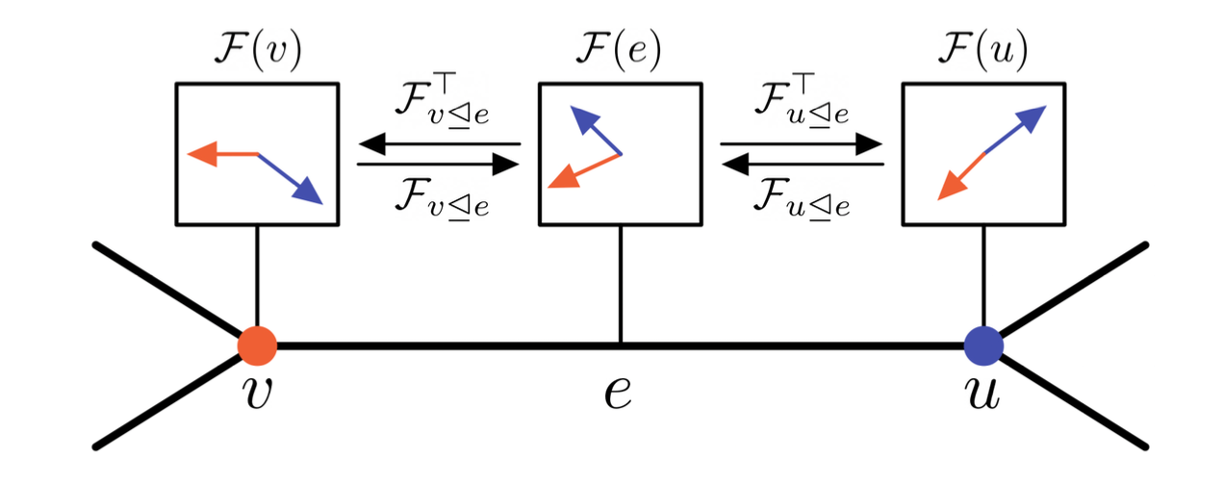

<a id="motivation--the-sheaf-laplacian"></a>
### 3.2 The Sheaf Laplacian

Why introduce this machinery? As we said Standard GNNs use the standard graph Laplacian to smooth features directly across edges. However, in **heterophilic** graphs this direct smoothing destroys valuable information.

Sheaves solve this by comparing *transported* features rather than raw features. Given an arbitrary edge orientation $e = (u \to v)$, we define the **coboundary map** $\delta: C^0(\mathcal{G}, \mathcal{F}) \to C^1(\mathcal{G}, \mathcal{F})$, which acts edgewise as:
$$\delta(\mathbf{x})_e \coloneqq \mathcal{F}_{v \trianglelefteq e}\mathbf{x}_v - \mathcal{F}_{u \trianglelefteq e}\mathbf{x}_u$$

This measures the **disagreement** between node $u$ and node $v$ only after their features have been projected into the shared edge stalk. 

From this, we construct the **Sheaf Laplacian** $L_{\mathcal{F}} \coloneqq \delta^{\top}\delta$, which admits the nodewise form:
$$L_{\mathcal{F}}(\mathbf{x})_u = \sum_{u,v \trianglelefteq e} \mathcal{F}_{u \trianglelefteq e}^{\top}\!\left(\mathcal{F}_{u \trianglelefteq e}\mathbf{x}_u - \mathcal{F}_{v \trianglelefteq e}\mathbf{x}_v\right)$$

In practice, we use the normalized version $\Delta_{\mathcal{F}} \coloneqq D^{-1/2} L_{\mathcal{F}} D^{-1/2}$, where $D$ is the block diagonal of $L_{\mathcal{F}}$. By learning the restriction maps from the data, the network learns a geometry tailored to the specific heterophily of the graph.

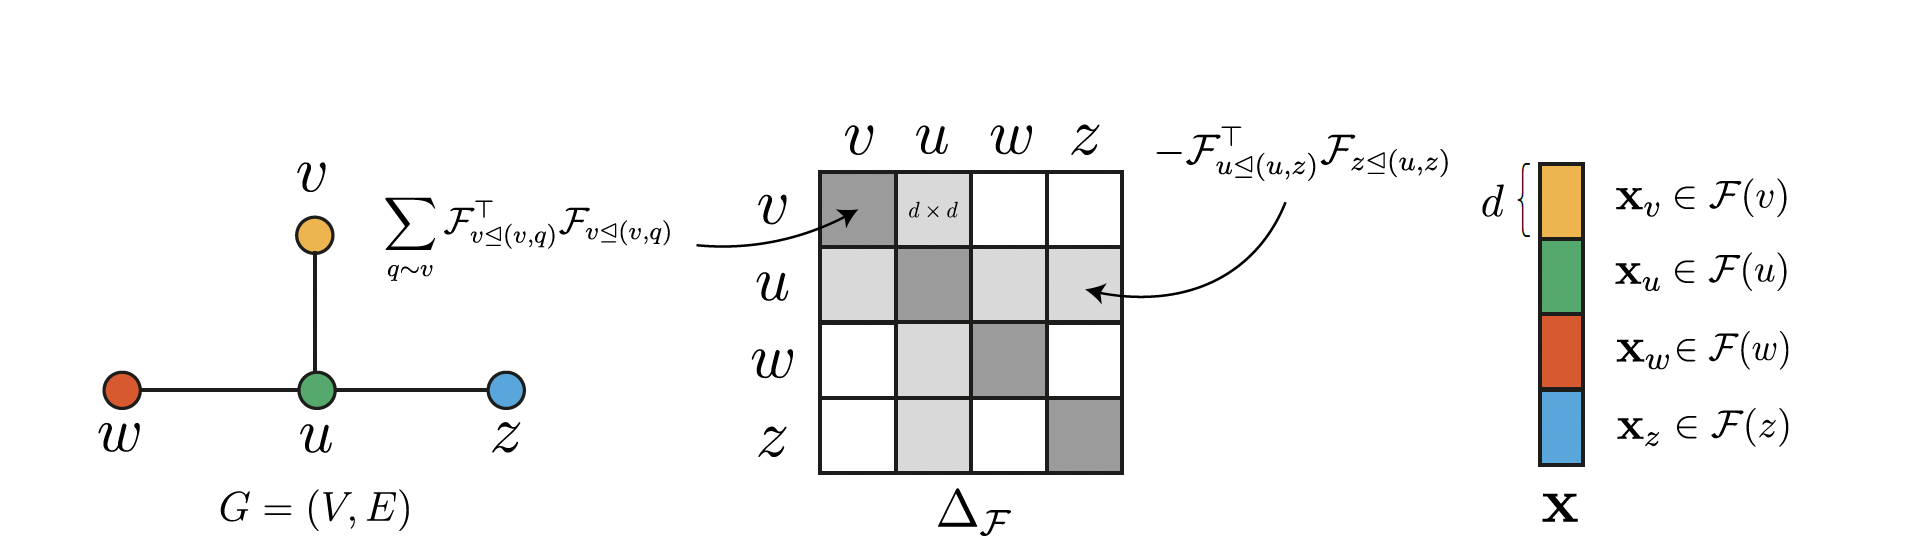

<a id="recovering-classical-graph-diffusion"></a>
### 3.3 Recovering Classical Graph Diffusion

To build intuition, it is helpful to see that SheafNNs are a strict generalization of standard GNNs. 

Consider what happens if we impose a highly restrictive structure on our sheaf:
1. We set the stalk dimension to $d = 1$ (meaning stalks are just scalars).
2. We force every restriction map $\mathcal{F}_{u \trianglelefteq e}$ to be the identity map (i.e., $1$).

Under these conditions, the transport equations become trivial: $\mathcal{F}_{u \trianglelefteq e}\mathbf{x}_u$ is simply $\mathbf{x}_u$. The nodewise sheaf Laplacian equation collapses entirely into the standard graph Laplacian:
$$L(\mathbf{x})_u = \sum_{v \in \mathcal{N}(u)} (\mathbf{x}_u - \mathbf{x}_v)$$

Consequently, a SheafNN model parameterized this way reduces precisely to a standard Graph Convolutional Network (GCN). The power of this framework lies in lifting this restriction, letting the model learn $d \times d$ matrix transformations (Diagonal, Orthogonal, or General) for every incident pair in the graph.

The following code demonstrates the progression from a standard **Graph Laplacian** to a **Sheaf Laplacian**. First, we compute classical graph diffusion on a simple path graph. Next, we verify that assigning identity restriction maps perfectly recovers this classical behavior. Finally, we introduce a non-trivial map (anisotropic damping) to observe how the sheaf structurally alters the flow of information across a specific edge.

In [37]:
# =====================================================================
# The Classical Graph Laplacian (Scalar Signal)
# =====================================================================
# Construct an undirected path graph: 0 -- 1 -- 2 -- 3
# Written in both orientations to represent undirected edges.
edge_index = torch.tensor(
    [
        [0, 1, 1, 2, 2, 3],
        [1, 0, 2, 1, 3, 2],
    ],
    dtype=torch.long,
)

# Define a 1D scalar node signal.
x_scalar = torch.tensor([[1.0], [2.0], [0.5], [3.0]])

def graph_laplacian_action(x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
    """Unnormalized Laplacian action: (Lx)_u = sum_{v in N(u)} (x_u - x_v)."""
    out = torch.zeros_like(x)
    for u, v in edge_index.t().tolist():
        out[u] += x[u] - x[v]
    return out

Lx = graph_laplacian_action(x_scalar, edge_index)

print("--- 1. Classical Graph Laplacian ---")
print("Scalar signal x:")
print(x_scalar.squeeze(-1))
print("\nGraph Laplacian action Lx:")
print(Lx.squeeze(-1))
print("\n")


# =====================================================================
# Sheaf Laplacian with Identity Maps (Recovering Standard GNNs)
# =====================================================================
# We lift the signal to a 2-dimensional stalk space (d=2) to demonstrate
# channel-wise transport.
X = torch.tensor(
    [
        [1.0,  0.0],
        [2.0,  1.0],
        [0.5, -1.0],
        [3.0,  2.0],
    ],
    dtype=torch.float,
)

def identity_sheaf_laplacian_action(X: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
    """Sheaf Laplacian with identity restriction maps on a toy graph."""
    out = torch.zeros_like(X)
    I = torch.eye(X.size(1), dtype=X.dtype)

    for u, v in edge_index.t().tolist():
        # F_{u|e} = I and F_{v|e} = I
        # Disagreement is measured directly in the shared edge stalk.
        disagreement = I @ X[u] - I @ X[v]
        out[u] += I.T @ disagreement

    return out

L_sheaf = identity_sheaf_laplacian_action(X, edge_index)

# To prove equivalence, apply the standard graph Laplacian to each channel independently.
L_channelwise = torch.stack(
    [
        graph_laplacian_action(X[:, k : k + 1], edge_index).squeeze(-1)
        for k in range(X.size(1))
    ],
    dim=-1,
)

print("--- 2. Identity Sheaf Laplacian vs Channel-wise Graph Laplacian ---")
print("Sheaf Laplacian with identity maps:")
print(L_sheaf)
print("\nChannel-wise graph Laplacian:")
print(L_channelwise)
print("\nThey match:", torch.allclose(L_sheaf, L_channelwise))
print("\n")


# =====================================================================
# Sheaf Laplacian (Anisotropic Transport)
# =====================================================================
# To see the Sheaf Laplacian diverge from standard graph diffusion 
# we use a symmetric, non-orthogonal matrix that damps the second feature channel across edge (1 <--> 2).

restriction_maps = {}
for u, v in edge_index.t().tolist():
    restriction_maps[(u, v)] = torch.eye(2, dtype=torch.float)

# Damping matrix: preserves the first channel, squashes the second to 20%
damp = torch.diag(torch.tensor([1.0, 0.2]))
restriction_maps[(1, 2)] = damp
restriction_maps[(2, 1)] = damp

def sheaf_laplacian_action(
    X: torch.Tensor,
    edge_index: torch.Tensor,
    restriction_maps: dict[tuple[int, int], torch.Tensor],
) -> torch.Tensor:
    """Computes the full Sheaf Laplacian using custom restriction matrices."""
    out = torch.zeros_like(X)
    for u, v in edge_index.t().tolist():
        F_u = restriction_maps[(u, v)]
        F_v = restriction_maps[(v, u)]
        
        # Calculate the disagreement in the edge stalk space
        disagreement = F_u @ X[u] - F_v @ X[v]
        
        # Pull the disagreement back into the node stalk space
        out[u] += F_u.T @ disagreement
    return out

L_nontrivial = sheaf_laplacian_action(X, edge_index, restriction_maps)

print("--- 3. Sheaf Laplacian (Anisotropic Transport) ---")
print("Sheaf Laplacian with non-orthogonal transport (damping channel 2 on edge 1-2):")
print(L_nontrivial)

--- 1. Classical Graph Laplacian ---
Scalar signal x:
tensor([1.0000, 2.0000, 0.5000, 3.0000])

Graph Laplacian action Lx:
tensor([-1.0000,  2.5000, -4.0000,  2.5000])


--- 2. Identity Sheaf Laplacian vs Channel-wise Graph Laplacian ---
Sheaf Laplacian with identity maps:
tensor([[-1.0000, -1.0000],
        [ 2.5000,  3.0000],
        [-4.0000, -5.0000],
        [ 2.5000,  3.0000]])

Channel-wise graph Laplacian:
tensor([[-1.0000, -1.0000],
        [ 2.5000,  3.0000],
        [-4.0000, -5.0000],
        [ 2.5000,  3.0000]])

They match: True


--- 3. Sheaf Laplacian (Anisotropic Transport) ---
Sheaf Laplacian with non-orthogonal transport (damping channel 2 on edge 1-2):
tensor([[-1.0000, -1.0000],
        [ 2.5000,  1.0800],
        [-4.0000, -3.0800],
        [ 2.5000,  3.0000]])


<a id="4-dataset-pipeline"></a>
# 4. Dataset Pipeline

GNNs require a slightly different data management paradigm than standard computer vision or NLP pipelines. Instead of loading batches of independent samples (like images or text tokens), we typically load a **single, massive interconnected graph** topology. 

In this section, we look at how the repository manages datasets. We will demonstrate how it automatically downloads graphs, standardizes different data formats into a uniform structure, and sets up the data splits used for model evaluation.

---

<a id="loading-datasets"></a>
### 4.1 Loading Datasets and Graph Inspection

We evaluate our models using a **transductive node classification** setup. Under this setup:
* The model sees the **entire graph topology** (the global adjacency matrix) and all node features during both training and inference.
* Information is strictly isolated during optimization using **boolean or index masks** (`train_mask`, `val_mask`, `test_mask`). Loss is computed *only* over the training nodes, preventing data leakage while allowing message passing to leverage the full structure.

In the repo `gen_splits.py` provides the split-generation utilities used to create or download the `.npz` files that define the fold-specific train/validation/test masks.

In [38]:
# =====================================================================
# Dataset Selection and Loading
# =====================================================================
# The repository supports various datasets. For this demonstration, we focus on 
# heterophilic graphs where standard GNNs fail. 

dataset_name = "texas"
print(f"--- Loading Dataset: {dataset_name.upper()} ---")

data, info = load_dataset(dataset_name)

# =====================================================================
# Global Graph Statistics and Metadata
# =====================================================================
print("\n--- 1. Metadata & Topology ---")
print(f"Dataset Name:       {info.name}")
print(f"Evaluation Metric:  {info.metric}")
print(f"Total Nodes:        {data.num_nodes}")
print(f"Total Edges:        {data.num_edges}")
print(f"Node Features (d):  {data.num_node_features}")
print(f"Target Classes (C): {info.num_classes}")

# =====================================================================
# Tensor Shape Inspection
# =====================================================================
# In PyTorch Geometric, graphs are represented as a single `Data` object 
# containing node features (x), labels (y), and sparse adjacency (edge_index).
print("\n--- 2. Underlying Tensor Shapes ---")
print(f"PyG Data Object: {data}")
print(f"Node Feature Matrix (data.x): {tuple(data.x.shape)}")
print(f"Target Labels (data.y):       {tuple(data.y.shape)}")
print(f"Edge Index (data.edge_index): {tuple(data.edge_index.shape)}")

# =====================================================================
# Class Distribution
# =====================================================================

labels, counts = torch.unique(data.y, return_counts=True)
print("\n--- 3. Class Distribution ---")
for label, count in zip(labels.tolist(), counts.tolist()):
    print(f"Class {label}: {count} nodes")

# =====================================================================
# Transductive Data Splits (Masks)
# =====================================================================
# In transductive node classification, the entire graph structure is passed 
# through the model, but we only compute loss/metrics on specific nodes 
# using boolean masks.

def mask_size(mask: torch.Tensor) -> int:
    """Utility to count the number of True values in a boolean mask."""
    return int(mask.sum().item())

if hasattr(data, "train_mask"):
    print("\n--- 4. Transductive Split Sizes ---")
    print(f"Train Mask Shape: {tuple(data.train_mask.shape)}")
    print(f"Val Mask Shape:   {tuple(data.val_mask.shape)}")
    print(f"Test Mask Shape:  {tuple(data.test_mask.shape)}")
    
    print("\nNode Allocations:")
    print(f"Training Nodes:   {mask_size(data.train_mask)}")
    print(f"Validation Nodes: {mask_size(data.val_mask)}")
    print(f"Testing Nodes:    {mask_size(data.test_mask)}")
else:
    print("\n--- 4. Transductive Splits ---")
    print("This dataset does not use PyG built-in masks. It relies on standard .npz split files.")

--- Loading Dataset: TEXAS ---

--- 1. Metadata & Topology ---
Dataset Name:       texas
Evaluation Metric:  acc
Total Nodes:        183
Total Edges:        325
Node Features (d):  1703
Target Classes (C): 5

--- 2. Underlying Tensor Shapes ---
PyG Data Object: Data(x=[183, 1703], edge_index=[2, 325], y=[183], train_mask=[183, 10], val_mask=[183, 10], test_mask=[183, 10])
Node Feature Matrix (data.x): (183, 1703)
Target Labels (data.y):       (183,)
Edge Index (data.edge_index): (2, 325)

--- 3. Class Distribution ---
Class 0: 33 nodes
Class 1: 1 nodes
Class 2: 18 nodes
Class 3: 101 nodes
Class 4: 30 nodes

--- 4. Transductive Split Sizes ---
Train Mask Shape: (183, 10)
Val Mask Shape:   (183, 10)
Test Mask Shape:  (183, 10)

Node Allocations:
Training Nodes:   870
Validation Nodes: 590
Testing Nodes:    370


<a id="5-neural-sheaf-diffusion"></a>
# 5. Neural Sheaf Diffusion

<a id="message-passing-formulation"></a>
### 5.1 Message Passing Formulation

Neural Sheaf Diffusion (NSD) is one of the possible instantiation of SheafMPNNs, it updates node features by diffusing them according to the geometry of the learned sheaf. We can express this using the **SheafMPNN** framework.

At layer $t$, we first apply a bilateral stalk transformation to the node features $\mathbf{x}_u^{(t)} \in \mathbb{R}^{d \times f}$. The matrix $\mathbf{W}_1 \in \mathbb{R}^{d \times d}$ mixes the stalk dimensions, while $\mathbf{W}_2 \in \mathbb{R}^{f \times f}$ acts as a standard feature channel filter:
$$\mathbf{z}_u^{(t)} = \mathbf{W}_1^{(t)}\mathbf{x}_u^{(t)}\mathbf{W}_2^{(t)}$$

Next, we compute the local disagreement (the sheaf Laplacian message) for each node by aggregating over its neighbors $v \in \mathcal{N}(u)$. For an edge $e$, let $\mathcal{F}_{u \trianglelefteq e}$ be the learned restriction map. The message is computed as:
$$\mathbf{m}^{(t+1)}_u = \sum_{u,v \trianglelefteq e} \mathcal{F}_{u \trianglelefteq e}^{\top}\!\left(\mathcal{F}_{u \trianglelefteq e}\mathbf{z}_u^{(t)} - \mathcal{F}_{v \trianglelefteq e}\mathbf{z}_v^{(t)}\right)$$

Finally, NSD uses a residual update rule scaled by a learnable diffusion step size $\alpha$, passed through a non-linear activation $\sigma$ (typically $\tanh$):
$$\mathbf{x}_u^{(t+1)} = \mathbf{x}_u^{(t)} - \alpha \sigma(\mathbf{m}^{(t+1)}_u)$$

*(Note: In practice, the library applies symmetric degree normalization to these messages, $D^{-1/2} L_{\mathcal{F}} D^{-1/2}$, to ensure stability across varying node degrees.)*

**Recovering Standard GNNs from SheafMPNN**
* If we fix $\mathcal{F}_{u \trianglelefteq e} = 1$ for all edges, the message $\mathbf{m}_u$ reduces to the standard Graph Laplacian operator $\sum (\mathbf{z}_u - \mathbf{z}_v)$. 

<a id="restriction-map-parameterizations"></a>
### 5.2 Restriction Maps parametrization

The expressive power of NSD comes from how we parameterize the restriction maps $\mathcal{F}_{u \trianglelefteq e}$. Instead of fixing them, we learn them dynamically from the incident node features: $\mathcal{F}_{u \trianglelefteq e} = \text{MLP}(\mathbf{x}_u \| \mathbf{x}_v)$. 

Our repository implements three distinct variants for these maps, offering a tradeoff between computational cost, expressivity, and numerical stability:

**1. Diagonal Maps (`DiagonalNSDConv`)**
* **Formulation:** Each restriction map is constrained to be a diagonal matrix, represented simply as a vector in $\mathbb{R}^d$.
* **Properties:** This is the most lightweight variant. Because the matrices are diagonal, the matrix multiplications in the message passing step reduce to element-wise multiplications, bringing the complexity down to $\mathcal{O}(|\mathcal{E}| \cdot d \cdot f)$.

**2. Orthogonal Maps (`OrthogonalNSDConv`)**
* **Formulation:** The maps are constrained to be orthogonal matrices (i.e., $\mathcal{F}^{\top}\mathcal{F} = \mathbf{I}_d$). The network predicts the upper-triangular entries of a skew-symmetric matrix, which is then mapped to the orthogonal group $O(d)$ using the **Cayley transform** (or Householder reflections).
* **Properties:** Because the maps are orthogonal, the diagonal term of the Sheaf Laplacian simplifies perfectly: $\mathcal{F}_{u \trianglelefteq e}^{\top} \mathcal{F}_{u \trianglelefteq e} = \mathbf{I}_d$. This guarantees that the transport does not alter vector norms, preventing vanishing and exploding gradients during deep message passing.

**3. General Maps (`GeneralNSDConv`)**
* **Formulation:** The MLP outputs a full, unconstrained $d \times d$ square matrix for every incident pair.
* **Properties:** This offers the highest expressivity, allowing complex linear combinations across the stalk dimensions. However, it requires more parameters ($\mathcal{O}(d^2)$ per edge) and can sometimes be susceptible to optimization instabilities if the matrix norms grow too large.

---

The code below initializes the three core (NSD) variants: **Diagonal**, **General**, and **Orthogonal**. We define the necessary geometric hyperparameters, most importantly the stalk dimension ($d$), and perform a preliminary forward pass through all three architectures to verify that the output shapes align perfectly with our target classes.

In [39]:
from sheaf_mpnn.utils import cayley, householder, attention_cayley
from sheaf_mpnn.nsd.nsd_model import NSDModel, NSDVariant
from sheaf_mpnn.nsd.nsd_layers import (
    DiagonalNSDConv,
    GeneralNSDConv,
    OrthogonalNSDConv,
)

# We utilize the dimensions from the dataset loaded in Section 4.
in_channels = data.num_node_features
out_channels = info.num_classes

# Hyperparameters controlling the stalk geometry:
d = 4             # Stalk dimension (the "geometric channel" size)
hidden_dim = 16   # Feature dimension per stalk
num_layers = 2    # Number of diffusion steps

print("--- Instantiating the Three NSD Variants ---")
# 1. Diagonal: Restriction maps are diagonal matrices (fastest, scales coordinates)
# 2. General: Restriction maps are full d x d matrices (most expressive)
# 3. Orthogonal: Restriction maps are strictly orthogonal matrices via Cayley transforms (stable)

models = {
    "diagonal": NSDModel(
        in_channels=in_channels, out_channels=out_channels,
        stalk_dim=d, hidden_dim=hidden_dim, num_layers=num_layers,
        variant=NSDVariant.DIAGONAL,
    ),
    "general": NSDModel(
        in_channels=in_channels, out_channels=out_channels,
        stalk_dim=d, hidden_dim=hidden_dim, num_layers=num_layers,
        variant=NSDVariant.GENERAL,
    ),
    "orthogonal": NSDModel(
        in_channels=in_channels, out_channels=out_channels,
        stalk_dim=d, hidden_dim=hidden_dim, num_layers=num_layers,
        variant=NSDVariant.ORTHOGONAL,
    ),
}

with torch.no_grad():
    for name, model in models.items():
        logits = model(data.x, data.edge_index)
        print(f"{name.capitalize():>10s} Model -> Logits Shape: {tuple(logits.shape)}")

--- Instantiating the Three NSD Variants ---
  Diagonal Model -> Logits Shape: (183, 5)
   General Model -> Logits Shape: (183, 5)
Orthogonal Model -> Logits Shape: (183, 5)


This snippet isolates the internal tensor flow of a single message-passing step. We first use a linear encoder to "lift" the raw node features into the higher-dimensional stalk space. These stalks are then flattened to create the context vectors that the convolutional layer uses to dynamically predict the restriction maps before executing the actual diffusion update.

In [40]:
print("\n--- Feature Lifting & Message Passing Flow ---")

# Step 1: The Linear Encoder
encoder = nn.Linear(in_channels, d * hidden_dim)

# Step 2: The NSD Convolution Layer
general_layer = GeneralNSDConv(
    stalk_dim=d,
    in_channels=hidden_dim,
    hidden_dim=hidden_dim,
    context_dim=d * hidden_dim,
)

with torch.no_grad():
    # Lift raw node features into the geometric stalk space.
    # [N, in_channels] -> [N, d, hidden_dim]
    x_stalk = encoder(data.x).view(-1, d, hidden_dim)

    # Flatten the stalk to produce the context used by the MLPs to predict the restriction maps.
    x_feat = x_stalk.reshape(x_stalk.size(0), -1)

    # Execute one NSD diffusion step: x^{(t+1)} = x^{(t)} - alpha * tanh(L_F(x^{(t)}))
    x_next = general_layer(x_feat, x_stalk, data.edge_index)

print(f"Stalk Tensor (x_stalk): {tuple(x_stalk.shape)} -> [Nodes, Stalk_Dim, Features]")
print(f"Context Feat (x_feat):  {tuple(x_feat.shape)} -> [Nodes, Flattened_Context]")
print(f"Updated Stalk (x_next): {tuple(x_next.shape)} -> Ready for next layer or decoding")


--- Feature Lifting & Message Passing Flow ---
Stalk Tensor (x_stalk): (183, 4, 16) -> [Nodes, Stalk_Dim, Features]
Context Feat (x_feat):  (183, 64) -> [Nodes, Flattened_Context]
Updated Stalk (x_next): (183, 4, 16) -> Ready for next layer or decoding


To understand what the network is actually learning, we need to look under the hood at the restriction maps themselves. The code below extracts the specific matrices generated for a single edge. By inspecting the untrained layers, we can see exactly how each variant (Diagonal, General, and Orthogonal) constructs its mathematical transformations from the raw node features before any optimization occurs.

In [41]:
print("\n--- Inspecting Edge-Specific Restriction Maps ---")

def inspect_edge_maps(layer, x_feat, edge_index, edge_id=0):
    """A helper function to extract restriction matrices from the PyG layer mechanics."""
    u, v = edge_index[:, edge_id].tolist()

    # The MLPs generate maps by concatenating the flattened features of both edge endpoints.
    uv = torch.cat([x_feat[v], x_feat[u]], dim=-1).unsqueeze(0)
    vu = torch.cat([x_feat[u], x_feat[v]], dim=-1).unsqueeze(0)

    if isinstance(layer, DiagonalNSDConv):
        # Predicts a vector, embeds it on the diagonal
        F_v = torch.diag_embed(layer.map_generator(uv)).squeeze(0)
        F_u = torch.diag_embed(layer.map_generator(vu)).squeeze(0)

    elif isinstance(layer, GeneralNSDConv):
        # Predicts the full d x d matrix directly
        F_v = layer.map_generator(uv).view(1, layer.stalk_dim, layer.stalk_dim).squeeze(0)
        F_u = layer.map_generator(vu).view(1, layer.stalk_dim, layer.stalk_dim).squeeze(0)

    elif isinstance(layer, OrthogonalNSDConv):
        # Predicts a skew-symmetric matrix and applies the Cayley transform
        raw_v = layer.map_generator(uv)
        raw_u = layer.map_generator(vu)
        F_v = cayley(raw_v, layer.stalk_dim, layer.clamp_val).squeeze(0)
        F_u = cayley(raw_u, layer.stalk_dim, layer.clamp_val).squeeze(0)
    else:
        raise TypeError(f"Unsupported layer type: {type(layer)}")

    return u, v, F_v, F_u

# Instantiate isolated layers for inspection
diag_layer = DiagonalNSDConv(stalk_dim=d, in_channels=hidden_dim, hidden_dim=hidden_dim, context_dim=d * hidden_dim)
orth_layer = OrthogonalNSDConv(stalk_dim=d, in_channels=hidden_dim, hidden_dim=hidden_dim, context_dim=d * hidden_dim)

for name, layer in [
    ("Diagonal", diag_layer),
    ("General", general_layer),
    ("Orthogonal", orth_layer),
]:
    u, v, F_v, F_u = inspect_edge_maps(layer, x_feat, data.edge_index, edge_id=0)
    
    print(f"\n{name} Variant | Edge ({u} -> {v})")
    print(f"Matrix Shape: {tuple(F_v.shape)}")
    print(f"F_v (Restriction Map for Node {v}):")
    
    # Print the matrix
    matrix_str = "\n".join(["  " + "  ".join([f"{val:6.3f}" for val in row]) for row in F_v.tolist()])
    print(matrix_str)


--- Inspecting Edge-Specific Restriction Maps ---

Diagonal Variant | Edge (0 -> 58)
Matrix Shape: (4, 4)
F_v (Restriction Map for Node 58):
   0.000   0.000   0.000   0.000
   0.000   0.000   0.000   0.000
   0.000   0.000  -0.000   0.000
   0.000   0.000   0.000  -0.000

General Variant | Edge (0 -> 58)
Matrix Shape: (4, 4)
F_v (Restriction Map for Node 58):
  -0.000  -0.000  -0.000  -0.000
  -0.000  -0.000   0.000   0.000
   0.000  -0.000   0.000  -0.000
   0.000   0.000   0.000  -0.000

Orthogonal Variant | Edge (0 -> 58)
Matrix Shape: (4, 4)
F_v (Restriction Map for Node 58):
   1.000  -0.000   0.000   0.000
   0.000   1.000  -0.000   0.000
  -0.000   0.000   1.000   0.000
  -0.000  -0.000  -0.000   1.000


Notice a fascinating mathematical property in the untrained outputs above: the **Diagonal** and **General** variants output near-zero matrices, while the **Orthogonal** variant outputs a perfect Identity matrix ($\mathbf{I}_d$). 

This happens because PyTorch (depending on the initialization) initializes linear layers with weights close to zero. 
* For the Diagonal and General variants, the network directly predicts the matrix values, resulting in zeros.
* The Orthogonal variant, however, predicts a skew-symmetric matrix $\mathbf{A} \approx \mathbf{0}$, and passes it through the **Cayley transform**: 
  $$\mathcal{F}_{u \trianglelefteq e} = (\mathbf{I}_d + \mathbf{A})^{-1}(\mathbf{I}_d - \mathbf{A})$$
  When $\mathbf{A} = \mathbf{0}$, this equation simplifies perfectly to $(\mathbf{I}_d)^{-1}(\mathbf{I}_d) = \mathbf{I}_d$. 

Because of this, the Orthogonal variant naturally initializes as a standard Graph Laplacian. It begins training by performing standard neighbor-averaging and gradually learns to deviate from it as optimization progresses, making it incredibly stable to train.

<a id="instantiating-nsd-models"></a>
### 5.3 Instatiating NSD model

Here, we construct the end-to-end PyTorch architectures, deploy them to the GPU (if available), and inspect the varying parameter overheads introduced by the three geometric restriction map variants.

In [42]:
# =====================================================================
# Hardware Setup & Full Model Instantiation
# =====================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Hardware ---")
print(f"Using device: {device}\n")

# We rebuild the models, explicitly moving them to the device.
models = {
    "diagonal": NSDModel(
        in_channels=in_channels, out_channels=out_channels,
        stalk_dim=d, hidden_dim=hidden_dim, num_layers=num_layers,
        variant=NSDVariant.DIAGONAL, alpha=1.0,
    ).to(device),
    "general": NSDModel(
        in_channels=in_channels, out_channels=out_channels,
        stalk_dim=d, hidden_dim=hidden_dim, num_layers=num_layers,
        variant=NSDVariant.GENERAL, alpha=1.0,
    ).to(device),
    "orthogonal": NSDModel(
        in_channels=in_channels, out_channels=out_channels,
        stalk_dim=d, hidden_dim=hidden_dim, num_layers=num_layers,
        variant=NSDVariant.ORTHOGONAL, alpha=1.0,
    ).to(device),
}

# =====================================================================
# Model Complexity & Parameter Counting
# =====================================================================
# How much overhead does learning the graph geometry add? 
# Let's compare the parameter counts of the three variants.

def count_parameters(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("--- Model Summaries & Parameter Counts ---")
for name, model in models.items():
    print(f"{name.capitalize():>10s} Variant -> Trainable parameters: {count_parameters(model):,}")


# =====================================================================
# Dissecting the End-to-End Architecture
# =====================================================================
# Let's peek inside the PyTorch Module to see how the full pipeline is wired.

demo_model = models["general"]
data_device = data.to(device)

print("\n--- Internal Architecture Pipeline ---")
print(f"1. Pre-processing: {demo_model.encoder} (Lifts features to stalks)")
print(f"2. Message Passing: {len(demo_model.layers)} sequential NSD layers")
print(f"3. Post-processing: {demo_model.decoder} (Projects stalks to class logits)")

# Inspect the properties of the actual layers inside the stack
first_layer = demo_model.layers[0]
print(f"\n--- Deep Dive: First NSD Stack Layer ---")
print(f"Type:          {type(first_layer).__name__}")
print(f"Stalk Dim (d): {first_layer.stalk_dim}")
print(f"Learned Alpha: {float(first_layer.alpha.detach().cpu()):.4f} (Learnable diffusion step)")


# =====================================================================
# Device Forward Pass Verification
# =====================================================================
# Finally, we verify that the full computational graph executes cleanly 
# on the hardware device.

demo_model.eval()
with torch.no_grad():
    out = demo_model(data_device.x, data_device.edge_index)

print("\n--- Forward Pass Consistency Check ---")
print(f"Output Logits Shape: {tuple(out.shape)} | Expected: {(data.num_nodes, out_channels)}")
print("First 3 node logits:")
print(out[:3].cpu().numpy())

--- Hardware ---
Using device: cpu

--- Model Summaries & Parameter Counts ---
  Diagonal Variant -> Trainable parameters: 114,191
   General Variant -> Trainable parameters: 114,599
Orthogonal Variant -> Trainable parameters: 114,259

--- Internal Architecture Pipeline ---
1. Pre-processing: Linear(in_features=1703, out_features=64, bias=True) (Lifts features to stalks)
2. Message Passing: 2 sequential NSD layers
3. Post-processing: Linear(in_features=64, out_features=5, bias=True) (Projects stalks to class logits)

--- Deep Dive: First NSD Stack Layer ---
Type:          GeneralNSDConv
Stalk Dim (d): 4
Learned Alpha: 1.0000 (Learnable diffusion step)

--- Forward Pass Consistency Check ---
Output Logits Shape: (183, 5) | Expected: (183, 5)
First 3 node logits:
[[-0.01402174  0.04513814 -0.1461454   0.01483169  0.01655373]
 [-0.00336507  0.0799795  -0.04465622  0.03105866 -0.02415562]
 [ 0.06033108 -0.05481436 -0.09555812  0.10529634  0.02781677]]


<a id="6-training-pipeline"></a>
# 6. Training Pipeline

<a id="experiment-configuration"></a>
### 6.1 Experiment Configuration

To keep experiments organized and reproducible, we define our hyperparameters using typed configuration objects. The code below specifies the dataset, geometric parameters, and optimizer settings.

In [43]:
# =====================================================================
# Imports and Configuration setup
# =====================================================================
import tempfile
from lightning import Trainer
from exp.module import SheafLightningModule

print("--- 1. Experiment Configuration ---")
# Build a compact demo configuration 
cfg = Config(
    dataset=DatasetConfig(name=dataset_name, root=str(REPO_ROOT / "exp" / "data")),
    model=ModelConfig(
        variant="general",  # We train the General variant here
        stalk_dim=4,
        hidden_dim=16,
        num_layers=2,
        alpha=1.0,
    ),
    reg=RegConfig(
        input_dropout=0.5,
        dropout=0.0,
    ),
    optim=OptimConfig(
        lr=0.01,
        weight_decay=5e-4,
        epochs=50,          
        early_stopping=10,  
        stop_strategy="loss",
    ),
    cv=CVConfig(
        folds=10,
        seed=SEED,
        min_acc=0.0,
    ),
    hardware=HardwareConfig(cuda=0),
    wandb=WandBConfig(enabled=False), # Disabled to avoid requiring an account for the demo
)

print("Configuration instantiated successfully.")

--- 1. Experiment Configuration ---
Configuration instantiated successfully.


<a id="data-and-model-modules"></a>
### 6.2 Data and Model Modules

Next, we wrap our data and architecture in PyTorch Lightning modules. The `DataModule` manages our transductive learning setup, keeping the graph topology static while shifting the boolean masks for train/val/test splits. The `LightningModule` wraps the raw PyTorch architecture alongside its optimizers and metric trackers.

In [44]:
# =====================================================================
# PyTorch Lightning DataModule Initialization
# =====================================================================
print("\n--- 2. Data Pipeline Setup ---")
# The DataModule handles data splitting and batching cleanly.
# For transductive tasks, the graph remains the same across folds; 
# only the boolean masks shift to change which nodes are evaluated.
fold = 0
datamodule = SheafDataModule(cfg.dataset.name, root=cfg.dataset.root, fold=fold)
datamodule.setup()

info = datamodule.info
print(f"Dataset:    {info.name}")
print(f"Metric:     {info.metric}")
print(f"Features:   {info.num_features}")
print(f"Classes:    {info.num_classes}")
print(f"Split Sizes (Train, Val, Test): {datamodule.split_sizes}")
print(f"Graph Homophily Level: {round(datamodule.homophily, 4)}")


# =====================================================================
# Lightning Module Initialization
# =====================================================================
print("\n--- 3. Model Wrapping ---")
# The LightningModule wraps the raw NSD model along with the optimizer,
# learning rate schedulers, and metric trackers (Accuracy / ROC-AUC).
lit_model = SheafLightningModule(cfg, info)

print("Model wrapped successfully. Summary:")
print(ModelSummary(lit_model, max_depth=1))


--- 2. Data Pipeline Setup ---
Dataset:    texas
Metric:     acc
Features:   1703
Classes:    5
Split Sizes (Train, Val, Test): (87, 59, 37)
Graph Homophily Level: 0.1077

--- 3. Model Wrapping ---
Model wrapped successfully. Summary:
  | Name  | Type     | Params | Mode  | FLOPs
---------------------------------------------------
0 | model | NSDModel | 114 K  | train | 0    
---------------------------------------------------
114 K     Trainable params
0         Non-trainable params
114 K     Total params
0.458     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode
0         Total Flops


<a id="training-execution"></a>
### 6.3 Training Execution

With our modules ready, we configure the PyTorch Lightning `Trainer`. We define callbacks for early stopping and automatic checkpointing to ensure we save the best-performing weights without overfitting. Finally, we launch the training loop and automatically evaluate the best weights on the isolated test set.

In [45]:
# =====================================================================
# Trainer Callbacks & Execution
# =====================================================================
print("\n--- 4. Training Execution ---")
# Determine whether we monitor validation loss or validation accuracy/AUC
monitor = "val_loss" if cfg.optim.stop_strategy == "loss" else f"val_{info.metric}"
ckpt_mode = "min" if cfg.optim.stop_strategy == "loss" else "max"

# We use a temporary directory to store the model checkpoints
with tempfile.TemporaryDirectory() as ckpt_dir:
    
    # Save the best weights based on validation performance
    checkpoint_cb = ModelCheckpoint(
        dirpath=ckpt_dir,
        monitor=monitor,
        mode=ckpt_mode,
        save_top_k=1,
        filename="best",
    )

    # Halt training early if the model stops improving
    early_stop_cb = EarlyStopping(
        monitor=monitor,
        patience=cfg.optim.early_stopping,
        mode=ckpt_mode,
    )

    # Instantiate the engine
    trainer = Trainer(
        max_epochs=cfg.optim.epochs,
        callbacks=[early_stop_cb, checkpoint_cb],
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=[cfg.hardware.cuda] if torch.cuda.is_available() else "auto",
        enable_progress_bar=True,
        enable_model_summary=False,
        log_every_n_steps=1,
    )

    # Execute the training loop
    print("Beginning training...")
    trainer.fit(lit_model, datamodule)
    
    # Automatically load the best checkpoint and evaluate on the isolated test mask
    print("\nEvaluating best model on Test split...")
    test_result = trainer.test(lit_model, datamodule, ckpt_path="best", verbose=False)[0]


--- 4. Training Execution ---
Beginning training...
Epoch 15: 100%|██████████| 1/1 [00:00<00:00, 72.52it/s, v_num=46, val_loss=0.782, val_acc=0.797, train_loss=0.0116]  

Evaluating best model on Test split...
Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 327.58it/s]


<a id="results-verification"></a>
### 6.4 Results Verification

Once the training and testing phases conclude, we extract and print the final performance metrics. This verifies how well our learned, data-dependent Sheaf Laplacian performed on the target classification task.

In [46]:
# =====================================================================
# Results Verification
# =====================================================================
print("\n--- 5. Final Results ---")
print("Raw Test Dictionary:")
print(test_result)
print(f"\nTarget Benchmark -> Best test {info.metric}: {test_result.get(f'test_{info.metric}', float('nan')):.4f}")


--- 5. Final Results ---
Raw Test Dictionary:
{'test_loss': 0.6581728458404541, 'test_acc': 0.7567567825317383}

Target Benchmark -> Best test acc: 0.7568


## 7. Configuration and Reproducibility

<a id="configuration-objects"></a>
### 7.1 Configuration Objects and Presets

To ensure reproducible research, this repository relies on configuration objects and provides built-in `PRESETS`, optimal, pre-tuned hyperparameters for standard benchmark datasets. The code below inspects our current configuration and retrieves the recommended baseline settings for our chosen dataset.

In [47]:
# =====================================================================
# Imports and Configuration Inspection
# =====================================================================
from copy import deepcopy
import pandas as pd

# We reuse the lightweight configuration (cfg) built in Section 6.
base_cfg = cfg

print("--- 1. Configuration Dataclasses ---")
# The repository uses Python dataclasses to prevent hyperparameter drift
print("Dataset Config:  ", base_cfg.dataset)
print("Model Config:    ", base_cfg.model)
print("Regularization:  ", base_cfg.reg)
print("Optimization:    ", base_cfg.optim)
print("Hardware:        ", base_cfg.hardware)

# =====================================================================
# Repository Presets
# =====================================================================
print("\n--- 2. Built-in Benchmark Presets ---")
print("Available presets:", sorted(preset_registry.list_keys()))

preset_name = dataset_name
preset = preset_registry.get_or_default(preset_name)

if preset:
    print(f"\nOptimal Preset for '{preset_name}':")
    # Pretty-print the preset dataclass
    if hasattr(preset, "__dataclass_fields__"):
        for k, v in asdict(preset).items():
            print(f"  {k}: {v}")
    else:
        print(preset)
else:
    print(f"No explicit preset found for {preset_name}.")

<a id="cross-validation"></a>
### 7.2 The Cross-Validation Loop

To evaluate our architecture, we run a multi-fold cross-validation. The loop below iterates through different data splits, training a fresh model from scratch on each fold while ensuring the underlying graph topology remains static.

In the repo `run.py` is the repository’s official cross-validation entry point, automating fold-by-fold training, checkpoint selection, and test metric aggregation.

In [48]:
# =====================================================================
# Cross-Validation Execution
# =====================================================================
import contextlib
import io
import logging
import tempfile

from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

# Silence Lightning / PyTorch Lightning loggers
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

print("\n--- 3. Multi-Fold Cross Validation ---")

results = []
num_folds = base_cfg.cv.folds

for fold in range(num_folds):
    print(f"\n=== Training Fold {fold + 1}/{num_folds} ===")

    datamodule = SheafDataModule(
        base_cfg.dataset.name,
        root=base_cfg.dataset.root,
        fold=fold,
    )
    datamodule.setup()
    info = datamodule.info

    lit_model = SheafLightningModule(base_cfg, info)

    monitor = "val_loss" if base_cfg.optim.stop_strategy == "loss" else f"val_{info.metric}"
    mode = "min" if base_cfg.optim.stop_strategy == "loss" else "max"

    with tempfile.TemporaryDirectory() as ckpt_dir:
        checkpoint_cb = ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor=monitor,
            mode=mode,
            save_top_k=1,
            filename="best",
        )
        early_stop_cb = EarlyStopping(
            monitor=monitor,
            patience=base_cfg.optim.early_stopping,
            mode=mode,
        )

        trainer = Trainer(
            max_epochs=base_cfg.optim.epochs,
            callbacks=[checkpoint_cb, early_stop_cb],
            accelerator="auto",
            devices="auto",
            logger=False,
            enable_progress_bar=False,
            enable_model_summary=False,
            log_every_n_steps=1,
        )

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            trainer.fit(lit_model, datamodule)

        best_model = SheafLightningModule.load_from_checkpoint(
            checkpoint_cb.best_model_path,
            cfg=base_cfg,
            info=info,
        )

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            test_result = trainer.test(
                best_model,
                datamodule,
                ckpt_path=None,
                verbose=False,
            )[0]

    fold_score = test_result.get(f"test_{info.metric}", np.nan)
    results.append(
        {
            "fold": fold,
            "metric": info.metric,
            "score": float(fold_score),
            "raw_result": test_result,
        }
    )

    print(f"-> Fold {fold + 1} Complete: test_{info.metric} = {fold_score:.4f}")


--- 3. Multi-Fold Cross Validation ---

=== Training Fold 1/10 ===
-> Fold 1 Complete: test_acc = 0.7838

=== Training Fold 2/10 ===
-> Fold 2 Complete: test_acc = 0.8108

=== Training Fold 3/10 ===
-> Fold 3 Complete: test_acc = 0.7297

=== Training Fold 4/10 ===
-> Fold 4 Complete: test_acc = 0.8108

=== Training Fold 5/10 ===
-> Fold 5 Complete: test_acc = 0.7568

=== Training Fold 6/10 ===
-> Fold 6 Complete: test_acc = 0.8108

=== Training Fold 7/10 ===
-> Fold 7 Complete: test_acc = 0.7568

=== Training Fold 8/10 ===
-> Fold 8 Complete: test_acc = 0.7027

=== Training Fold 9/10 ===
-> Fold 9 Complete: test_acc = 0.7568

=== Training Fold 10/10 ===
-> Fold 10 Complete: test_acc = 0.8649


<a id="results-aggregation"></a>
### 7.3 Statistical Aggregation

Once all training folds are complete, we compile the individual test scores into a single table. By calculating the mean and standard deviation across all splits, we obtain a statistically robust benchmark score that accurately reflects the model's true generalization capabilities.

In [49]:
# =====================================================================
# Results Aggregation
# =====================================================================
print("\n--- 4. Statistical Summary ---")

# Convert results into a Pandas DataFrame for clean visualization
results_df = pd.DataFrame([
    {
        "Fold": r["fold"],
        "Metric": r["metric"],
        "Score": r["score"],
    }
    for r in results
])

# Display the table
try:
    display(results_df)
except NameError:
    print(results_df)

# Calculate final statistics
mean_score = results_df["Score"].mean()
std_score = results_df["Score"].std(ddof=1)

print(f"\nFinal Architecture Performance on {base_cfg.dataset.name.upper()}:")
print(f"  Mean {results_df['Metric'].iloc[0]}: {mean_score:.4f}")
print(f"  Std  {results_df['Metric'].iloc[0]}: {std_score:.4f}")

# Optional: Inspect the raw logged metrics for the final fold
print(f"\nDiagnostic: Raw Lightning logs for Fold {results[-1]['fold']}")
for k, v in results[-1]["raw_result"].items():
    print(f"  {k}: {v}")


--- 4. Statistical Summary ---


,Fold,Metric,Score
0,0,acc,0.783784
1,1,acc,0.810811
2,2,acc,0.729730
3,3,acc,0.810811
4,4,acc,0.756757
5,5,acc,0.810811
6,6,acc,0.756757
7,7,acc,0.702703
8,8,acc,0.756757
9,9,acc,0.864865



Final Architecture Performance on TEXAS:
  Mean acc: 0.7784
  Std  acc: 0.0473

Diagnostic: Raw Lightning logs for Fold 9
  test_loss: 0.3883189558982849
  test_acc: 0.8648648858070374


For large-scale hyperparameter optimization, the repository provides `sweep.py`, which is the Optuna-based hyperparameter search entry point, sampling model and optimization settings across multiple seeds and trials.

## 8. Interpreting Learned Sheaf Geometry

<a id="global-map-extraction"></a>
### 8.1 Global Map Extraction

Before generating our visual analytics, we must extract the restriction maps for the entire graph. By concatenating the features of all connected nodes simultaneously, we can leverage PyTorch's batched operations to efficiently compute the transport matrices for every single edge at once.

In [50]:
# =====================================================================
# Global Map Extraction & Live Context Preparation
# =====================================================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# fallback in case umap is not installed in the notebook environment
try:
    from umap import UMAP
except ImportError:
    UMAP = None
    print("Note: 'umap-learn' is not installed. UMAP clustering will be skipped.")

# Re-extract required data
if 'analysis_data' not in locals():
    device = next(lit_model.parameters()).device
    analysis_data = data.to(device)
    first_layer = lit_model.model.layers[0] if hasattr(lit_model, 'model') else lit_model.layers[0]
    
    with torch.no_grad():
        x_stalk = lit_model.model.encoder(analysis_data.x).view(-1, first_layer.stalk_dim, first_layer.in_channels)
        x_feat = x_stalk.reshape(x_stalk.size(0), -1)

print("--- 1. Extracting All Edge Maps ---")
# Concatenate context for all edges simultaneously to leverage batching
all_u = analysis_data.edge_index[0]
all_v = analysis_data.edge_index[1]
all_uv_contexts = torch.cat([x_feat[all_v], x_feat[all_u]], dim=-1)

with torch.no_grad():
    if isinstance(first_layer, DiagonalNSDConv):
        all_maps = first_layer.map_generator(all_uv_contexts).cpu().numpy()
    elif isinstance(first_layer, GeneralNSDConv):
        all_maps = first_layer.map_generator(all_uv_contexts).view(all_u.size(0), -1).cpu().numpy()
    elif isinstance(first_layer, OrthogonalNSDConv):
        raw_maps = first_layer.cayley(first_layer.map_generator(all_uv_contexts))
        all_maps = raw_maps.view(all_u.size(0), -1).cpu().numpy()

print(f"Extracted transport matrix for {all_maps.shape[0]} edges.")
print(f"Flattened dimensions per edge: {all_maps.shape[1]}\n")

Note: 'umap-learn' is not installed. UMAP clustering will be skipped.
--- 1. Extracting All Edge Maps ---
Extracted transport matrix for 325 edges.
Flattened dimensions per edge: 16



<a id="heatmap-analysis"></a>
### 8.2 Visualization Utilities

We define a set of helper functions to visualize the learned restriction maps

In [51]:
# =====================================================================
# Visual Analytics Functions
# =====================================================================

def plot_heatmap_inline(layer_name, matrix_np, cmap="coolwarm"):
    """
    Visualise every edge × dimension entry.
    Interpretation:
        - Horizontal bands with similar hues indicate cohorts of edges sharing transports.
        - Saturated colors reveal near-binary behaviour; pale areas mean weak transports.
    """
    nrows, ncols = matrix_np.shape
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(matrix_np, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_title(f"{layer_name} Heatmap | shape {matrix_np.shape}")
    ax.set_xlabel("Restriction dimension")
    ax.set_ylabel("Edge index")
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels([str(i) for i in range(ncols)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

def plot_histogram_inline(layer_name, matrix_np):
    """
    Plot a histogram for each restriction dimension.
    Interpretation:
        - Multi-modal curves suggest the learner split edges into regimes.
        - Narrow spikes centred at zero imply that dimension carries little information.
    """
    dims = matrix_np.shape[1]
    fig, axes = plt.subplots(dims, 1, figsize=(8, 2 * dims), sharex=True)
    if dims == 1: axes = [axes]
    
    for idx, ax in enumerate(axes):
        ax.hist(matrix_np[:, idx], bins=50, alpha=0.7, color="steelblue")
        ax.set_ylabel(f"dim {idx}")
    
    axes[-1].set_xlabel("Restriction value")
    fig.suptitle(f"{layer_name} Distribution per Dimension", y=1.02)
    fig.tight_layout()
    plt.show()

def plot_clusters_inline(layer_name, matrix_np, mode='pca'):
    """
    Run dimensionality reduction on the per-edge transports and scatter in 2-D.
    Interpretation:
        - Well-separated blobs imply the sheaf learned distinct regimes.
        - A tight ball around the origin means transports collapsed, potentially underfitting.
    """
    flattened = matrix_np.reshape(matrix_np.shape[0], -1)
    if flattened.shape[0] < 2: return
    
    if mode == 'pca':
        model = PCA(n_components=2)
        label = "PC"
    elif mode == 'tsne':
        model = TSNE(n_components=2, random_state=42)
        label = "t-SNE"
    elif mode == 'umap':
        if UMAP is None: return
        model = UMAP(n_components=2, random_state=42)
        label = "UMAP"
    else:
        raise ValueError(f"Unknown mode {mode}")

    proj = model.fit_transform(flattened)
    norms = np.linalg.norm(flattened, axis=1)

    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=norms, cmap="viridis", s=5, alpha=0.8)
    
    title = f"{layer_name} {label} Scatter"
    if mode == 'pca':
        var = model.explained_variance_ratio_.sum() * 100
        title += f" | Var={var:.1f}%"
        
    ax.set_title(title)
    ax.set_xlabel(f"{label} 1")
    ax.set_ylabel(f"{label} 2")
    plt.colorbar(scatter, ax=ax, label="Edge transport norm")
    fig.tight_layout()
    plt.show()

def plot_topk_inline(layer_name, matrix_np, k=3):
    """
    Bar-chart the highest-norm edge transports for manual inspection.
    Interpretation:
        - Confirms what an “extreme” transport looks like per dimension.
        - Deviations here can hint at bad edges (e.g., exploding values).
    """
    flattened = matrix_np.reshape(matrix_np.shape[0], -1)
    norms = np.linalg.norm(flattened, axis=1)
    if norms.size == 0: return
    
    top_indices = np.argsort(norms)[-k:][::-1]
    
    fig, axes = plt.subplots(1, k, figsize=(k * 4, 3), sharey=True)
    if k == 1: axes = [axes]
    
    for rank, (edge_idx, ax) in enumerate(zip(top_indices, axes), start=1):
        ax.bar(np.arange(matrix_np.shape[1]), matrix_np[edge_idx], color="coral")
        ax.set_title(f"Rank {rank} (Edge {edge_idx})\nNorm: {norms[edge_idx]:.3f}")
        ax.set_xlabel("Dimension")
        
    axes[0].set_ylabel("Value")
    fig.suptitle(f"{layer_name} | Top {k} Exemplar Edges", y=1.08)
    plt.show()

<a id="heatmap-analysis"></a>
### 8.3 Heatmap Analysis

Our first visualization is a global heatmap of the transport matrices. This provides a bird's-eye view of the layer's behavior. We look for horizontal bands (indicating cohorts of edges that share similar transport rules) and saturated colors (indicating confident, high-magnitude geometric transformations).

--- 2. Generating Visual Analytics Dashboard ---


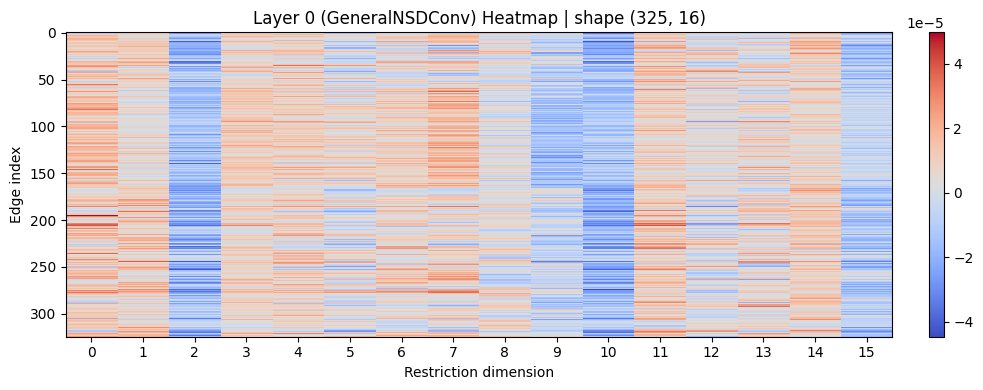

In [52]:
print("--- 2. Generating Visual Analytics Dashboard ---")

layer_label = f"Layer 0 ({type(first_layer).__name__})"

plot_heatmap_inline(layer_label, all_maps)

<a id="marginal-distributions"></a>
### 8.4 Marginal Distributions

Next, we plot the histograms of the learned restriction values across each geometric dimension. This reveals how the network utilizes its capacity: it shows whether a dimension is actively exploring a wide range of values, splitting into distinct multi-modal regimes, or if it has collapsed to zero.

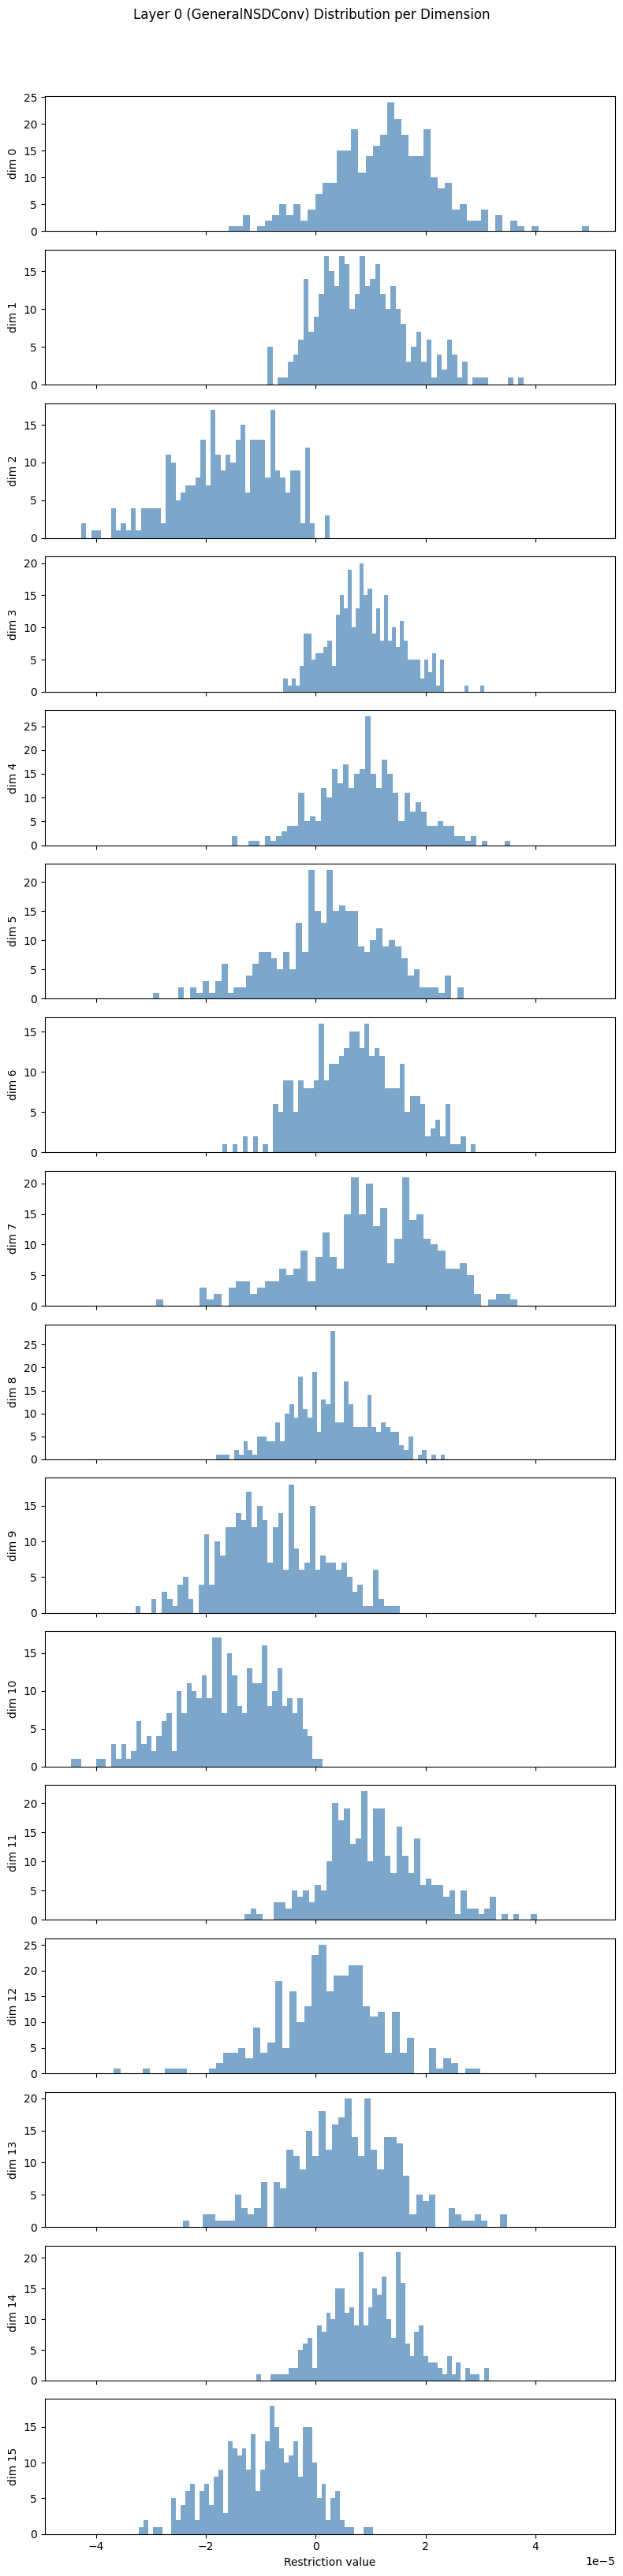

In [53]:
plot_histogram_inline(layer_label, all_maps)

<a id="geometric-clustering"></a>
### 8.5 Geometric Clustering

Does the model learn to categorize edges? By applying dimensionality reduction (like PCA, t-SNE, or UMAP) to the flattened transport matrices, we can visualize the edge embeddings in 2D space. Well-separated clusters imply the sheaf has discovered distinct structural or functional roles for different edges in the graph.

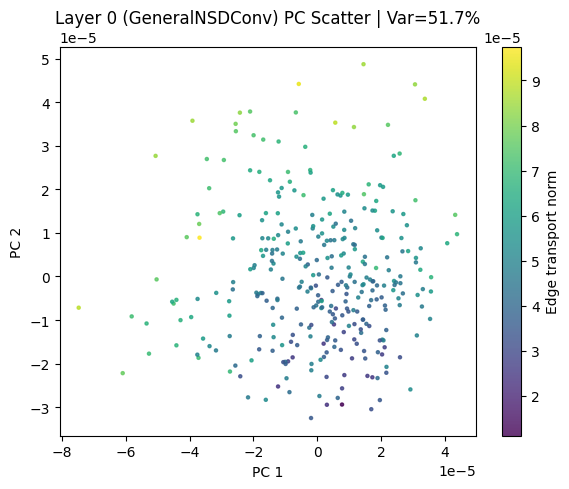

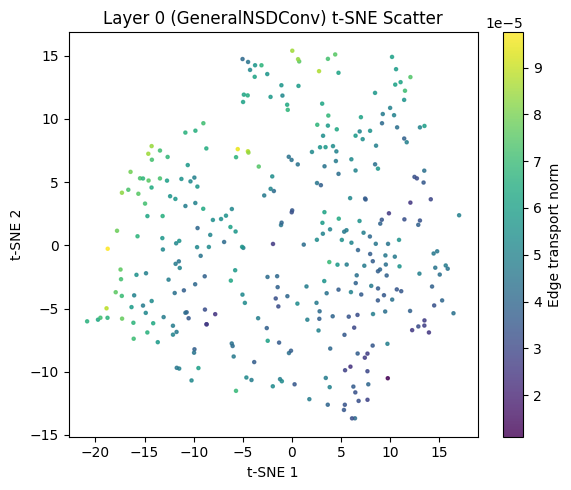

In [54]:
# Clustering comparisons
plot_clusters_inline(layer_label, all_maps, mode='pca')

plot_clusters_inline(layer_label, all_maps, mode='tsne')
if UMAP is not None:
    plot_clusters_inline(layer_label, all_maps, mode='umap')

<a id="top-k-exemplars"></a>
### 8.6 Top-K Exemplar Edges

Finally, rather than looking at macroscopic trends, we isolate the specific edges with the highest transport matrix norms. These "exemplar" edges represent the locations in the graph where the model chose to apply the most extreme geometric distortions, making them prime candidates for manual graph inspection.

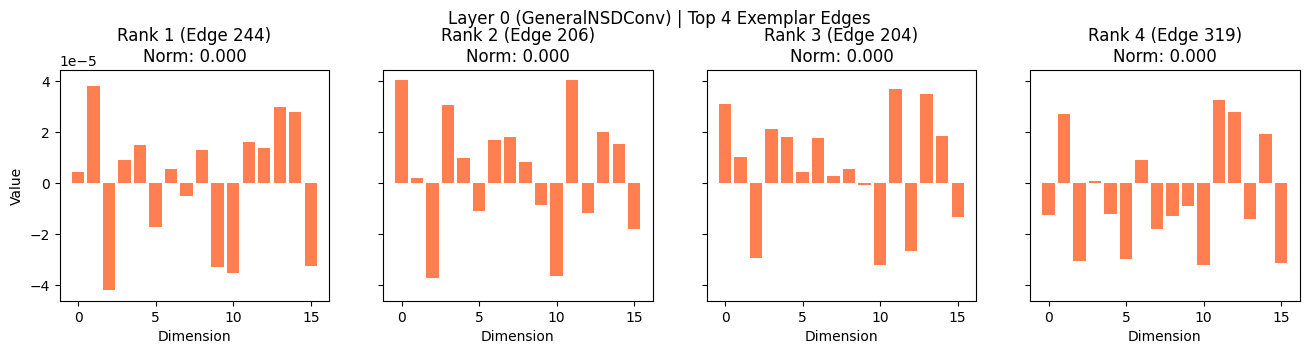

In [55]:

plot_topk_inline(layer_label, all_maps, k=4)